# DataSciencester

Uma rede social ficticia para praticar conceitos basicos de dados.

## Encontrando Conectores-Chaves

Medindo quem esta mais conectado dentro da rede.

In [1]:
# Dados iniciais: usuarios e pares de amizade da rede

users = [
    {"id": 0, "name": "Hero"},
    {"id": 1, "name": "Dunn"},
    {"id": 2, "name": "Sue"},
    {"id": 3, "name": "Chi"},
    {"id": 4, "name": "Thor"},
    {"id": 5, "name": "Clive"},
    {"id": 6, "name": "Hicks"},
    {"id": 7, "name": "Davin"},
    {"id": 8, "name": "Kate"},
    {"id": 9, "name": "Klein"},
]

friendship_pairs = [(0,1),(0,2),(1,2),(1,3),(2,3),(3,4),
                    (4,5),(5,6),(5,7),(6,8),(7,8),(8,9)]

Figura 1-1 - A rede DataScienceter

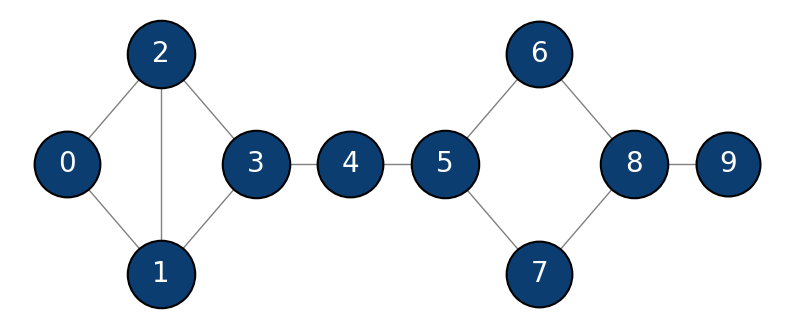

In [2]:
# Opcional - Visualiza a rede como um grafo simples

import matplotlib.pyplot as plt

def coordinates(user_id):
    x = user_id - (user_id >= 2) - (user_id >= 7)
    y = 3 if user_id in {2, 6} else 1 if user_id in {1, 7} else 2
    return x, y

plt.figure(figsize=(10, 4))

for i, j in friendship_pairs:
    x_values, y_values = zip(coordinates(i), coordinates(j))
    plt.plot(x_values, y_values, color="gray", linewidth=1, zorder=1)

for user in users:
    user_id = user["id"]
    x, y = coordinates(user_id)
    num_friends = sum(user_id in pair for pair in friendship_pairs)
    plt.scatter(
        x, y,
        s=2000 + 120 * num_friends,
        color="#0B3D70",
        edgecolors="black",
        linewidths=1.5,
        zorder=2
    )
    plt.text(x, y, str(user_id), color="white", ha="center", va="center", fontsize=20)

plt.xlim(-0.6, 7.6)
plt.ylim(0.6, 3.4)
plt.axis("off")
plt.show()

Monta um mapa de amizades por usuario 

In [3]:
# Inicialize o dict com uma lista vazia para cada id de usuario:
friendships = {user["id"]: [] for user in users}

# Em seguida, execute um loop pelos pares de amigos para preenche-la:
for i, j in friendship_pairs:
    friendships[i].append(j)
    friendships[j].append(i)

print(friendships)

{0: [1, 2], 1: [0, 2, 3], 2: [0, 1, 3], 3: [1, 2, 4], 4: [3, 5], 5: [4, 6, 7], 6: [5, 8], 7: [5, 8], 8: [6, 7, 9], 9: [8]}


In [4]:
# Calcula metricas simples da rede

def number_of_friends(user):
    """Quantos amigos tem o _user_?"""
    user_id = user["id"]
    friends_ids = friendships[user_id]
    return len(friends_ids)

total_conections = sum(number_of_friends(user)  # 24
                       for user in users)

num_user = len(users)  # Tamanho da lista de usuarios
avg_conections = total_conections/num_user   # 24 / 10 == 2.4

print(f"Tamanho da lista de usuarios: {num_user}")
print(f"Numero medio de conexoes: {avg_conections}")

Tamanho da lista de usuarios: 10
Numero medio de conexoes: 2.4


In [5]:
# Crie uma lista (user_id, number_of_friends)
num_friends_by_id =[(user["id"], number_of_friends(user))
                    for user in users]

num_friends_by_id.sort(
    key=lambda id_and_friends: id_and_friends[1],
    reverse=True)

print(num_friends_by_id)

[(1, 3), (2, 3), (3, 3), (5, 3), (8, 3), (0, 2), (4, 2), (6, 2), (7, 2), (9, 1)]


Figura 1-2 - A rede DataScienceter dimensionada de acordo com o grau

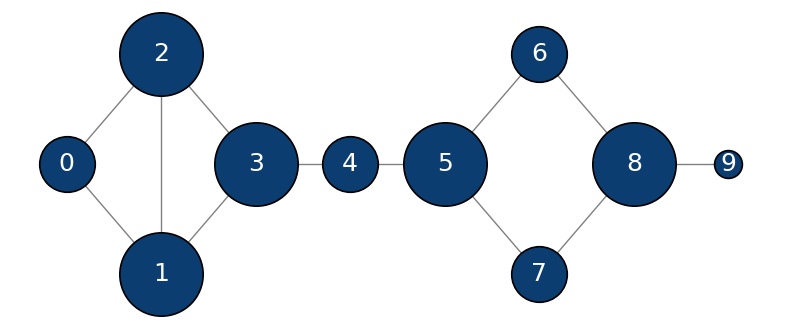

In [6]:
# Desenha a rede com vertices proporcionais ao grau.

plt.figure(figsize=(10, 4))

for i, j in friendship_pairs:
    x_values, y_values = zip(coordinates(i), coordinates(j))
    plt.plot(x_values, y_values, color="gray", linewidth=1, zorder=1)

for user in users:
    user_id = user["id"]
    degree = len(friendships[user_id])
    x, y = coordinates(user_id)
    plt.scatter(
        x, y,
        s=400 * (degree**2),
        color="#0B3D70",
        edgecolors="black",
        linewidths=1.2,
        zorder=2
    )
    plt.text(x, y, str(user_id), color="white", ha="center", va="center", fontsize=18)

plt.xlim(-0.6, 7.6)
plt.ylim(0.6, 3.4)
plt.axis("off")
plt.show()

## Cientista de Dados Que Você Talvez Conheça

*subtitulo

In [7]:
def foaf_ids_bad(user):
    """foaf significa "Friend of a Friend" [Amigo de um Amigo] """
    return [foaf_id
            for friend_id in friendships[user["id"]]
            for foaf_id in friendships[friend_id]
    ]

foaf_ids_bad(users[0])

[0, 2, 3, 0, 1, 3]

In [8]:
from collections import Counter

def friends_of_friends(user):
    user_id = user["id"]
    return Counter(
        foaf_id
        for friend_id in friendships[user_id]
        for foaf_id in friendships[friend_id]
        if foaf_id != user_id 
        and foaf_id not in friendships[user_id]
    )

friends_of_friends(users[3])

Counter({0: 2, 5: 1})

In [9]:
interests = [
    (0, "Hadoop"), (0, "Big Data"), (0, "HBase"), (0, "Java"), (0, "Spark"), (0, "Storm"), (0, "Cassandra"),
    (1, "NoSQL"), (1, "MongoDB"), (1, "Cassandra"), (1, "HBase"), (1, "Postgres"), 
    (2, "Python"), (2, "scikit-learn"), (2, "scipy"), (2, "numpy"), (2, "statsmodels"), (2, "pandas"),
    (3, "R"), (3, "Python"), (3, "statistics"), (3, "regression"), (3, "probability"),
    (4, "machine learning"), (4, "regression"), (4, "decision trees"), (4, "libsvm"),
    (5, "Python"), (5, "R"), (5, "Java"), (5, "C++"), (5, "Haskell"), (5, "programming languages"), 
    (6, "statistics"), (6, "probability"), (6, "mathematics"), (6, "theory"), 
    (7, "machine learning"), (7, "scikit-learn"), (7, "Mahout"), (7, "neural networks"),
    (8, "Big Data"), (8, "artificial intelligence"), (8, "neural networks"), (8, "deep learning"), 
    (9, "Hadoop"), (9, "Java"), (9, "MapReduce"), (9, "Big Data"), 
]

In [10]:
def data_scientists_who_liike(target_interest):
    """Encontre os ids dos usuarios com o mesmo interesse."""
    return[user_id
        for user_id, user_interests in interests
        if user_interests == target_interest
    ]

data_scientists_who_liike("Big Data")

[0, 8, 9]

In [11]:
from collections import defaultdict

user_ids_by_interest = defaultdict(list)

for user_id, interest in interests:
    user_ids_by_interest[interest].append(user_id)

interests_by_user_id = defaultdict(list)

for user_id, interest in interests:
    interests_by_user_id[user_id].append(interest)

In [12]:
def most_common_interests_with(user):
    return Counter(
        interested_user_id
        for interest in interests_by_user_id[user["id"]]
        for interested_user_id in user_ids_by_interest[interest]
        if interested_user_id != user["id"]
    )

most_common_interests_with(users[0])

Counter({9: 3, 1: 2, 8: 1, 5: 1})

### Salários e Experiência

*subtitulo

In [13]:
salaries_and_tenures = [(83000, 8.7), (88000, 8.1),
                        (48000, 0.7), (76000, 6),
                        (69000, 6.5), (76000, 7.5),
                        (60000, 2.5), (83000, 10),
                        (48000, 1.9), (63000, 4.2)]

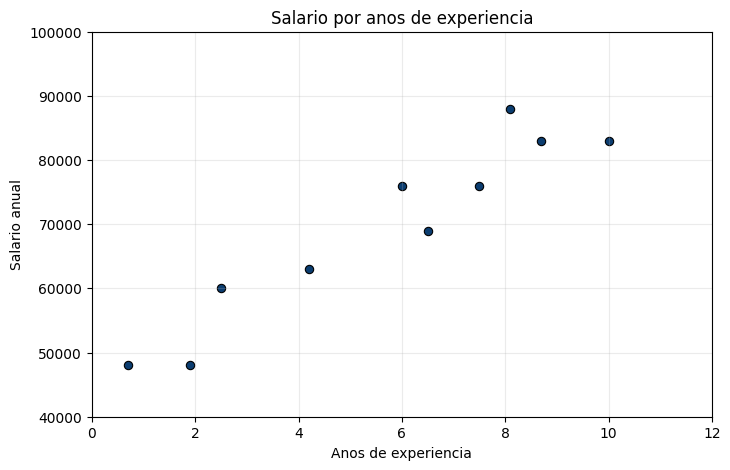

In [14]:
# Visualiza a relacao entre experiencia e salario.

years = [tenure for salary, tenure in salaries_and_tenures]
salaries = [salary for salary, tenure in salaries_and_tenures]

plt.figure(figsize=(8, 5))
plt.scatter(years, salaries, color="#0B3D70", edgecolors="black", linewidths=0.8)

plt.title("Salario por anos de experiencia")
plt.xlabel("Anos de experiencia")
plt.ylabel("Salario anual")
plt.xticks(range(0, 13, 2))
plt.yticks(range(40000, 100001, 10000))
plt.xlim(0, 12)
plt.ylim(40000, 100000)
plt.grid(True, alpha=0.25)
plt.show()

In [15]:
salary_by_tenure = defaultdict(list)

for salary, tenure in salaries_and_tenures:
    salary_by_tenure[tenure].append(salary)

average_salary_by_tenure = {
    tenure: sum(salaries) / len(salaries)
    for tenure, salaries in salary_by_tenure.items()
}

average_salary_by_tenure

{8.7: 83000.0,
 8.1: 88000.0,
 0.7: 48000.0,
 6: 76000.0,
 6.5: 69000.0,
 7.5: 76000.0,
 2.5: 60000.0,
 10: 83000.0,
 1.9: 48000.0,
 4.2: 63000.0}

In [16]:
def tenure_bucket(tenure):
    if tenure < 2:
        return "less than two"
    elif tenure < 5:
        return "between two and five"    
    else:
        return "more than five"  

In [17]:
salary_by_tenure_bucket =  defaultdict(list)

for salary, tenure in salaries_and_tenures:
    bucket = tenure_bucket(tenure)
    salary_by_tenure_bucket[bucket].append(salary)

In [22]:
average_salary_by_bucket = {
    tenure_bucket: sum(salaries) / len(salaries)
    for tenure_bucket, salaries in salary_by_tenure_bucket.items()
}

average_salary_by_bucket

{'more than five': 79166.66666666667,
 'less than two': 48000.0,
 'between two and five': 61500.0}

### Contas Pagas

*subtitulo

In [ ]:
def predict_paid_or_unpaid(years_experience):
    if tenure < 3.0:
        return "paid"
    elif tenure < 8.5:
        return "unpaid"    
    else:
        return "paid"  